In [1]:
import pandas as pd
import numpy as np
from scipy import stats

from pandas.api.types import CategoricalDtype

stationProximityDataSet = pd.read_csv("data/benz-tr.csv")

# Drop rows where country is not czechia

stationProximityDataSet = stationProximityDataSet[stationProximityDataSet.country == "cze"]

major_cities = ["praha", "brno", "ostrava", "liberec", "plzen", 
                "olomouc", "budejovice", "hradec kralove", 
                "pardubice", "usti nad labem", "zlin", "havirov", "kladno", "most", "opava", "jihlava", "frydek-mistek", "teplice", "karvina", "karlovy vary",
                "chomutov", "decin", "mlada boleslav", "jablonec nad nisou", "prostejov", "prerov", "trinec" ]

# without cities

stationProximityDataSet = stationProximityDataSet[~stationProximityDataSet['city'].str.lower().isin(major_cities)]


print("\nCount of transactions in Czechia: ", stationProximityDataSet.shape[0])

# Lets consider rows which have the same amnt, day, hour, clid to be duplicate and drop them
duplicateSubset = subset=["amt", "day", "hour", "clid"]
print('\nCount of duplicated rows: ',
      sum(stationProximityDataSet.duplicated(subset=duplicateSubset)))

stationProximityDataSet = stationProximityDataSet.drop_duplicates(subset=duplicateSubset)

# Drop useless columns
stationProximityDataSet = stationProximityDataSet.drop(columns=["clst", "clid", "day", "hour", "fav", "fav_main", "cl_gps_lat", "cl_gps_lon", "city", "name", "dist", "country"])

stationsWithDifferingGPS = stationProximityDataSet.groupby("posid", as_index=False).agg(
    total_amt=("amt", "sum"),
    gps_lat=("pos_gps_lat", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    gps_lon=("pos_gps_lon", lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

duplicateSubset = ["gps_lat", "gps_lon"]

print('\nCount of duplicated gps locations: ',
      sum(stationsWithDifferingGPS.duplicated(subset=duplicateSubset)))
# This is problematic because some stations share same gps location
# But considering that the gps is in most cases if not all cases precise for 5-6 decimal points which is 0.1m precision, we will consider them as one station

stationsWithDifferingGPS = stationProximityDataSet.groupby("posid", as_index=False).agg(
    total_amt=("amt", "sum"),
    gps_lat=("pos_gps_lat", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    gps_lon=("pos_gps_lon", lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

stationsWithDifferingGPS = stationsWithDifferingGPS.groupby(['gps_lat', 'gps_lon'], as_index=False).agg(
    total_amt=('total_amt', 'sum'),
    posid=('posid', 'first')
)

print('Count of stations', stationsWithDifferingGPS.shape[0])
stationsWithDifferingGPS


Count of transactions in Czechia:  1313151

Count of duplicated rows:  572

Count of duplicated gps locations:  597
Count of stations 1920


,gps_lat,gps_lon,total_amt,posid
0,48.587223,14.322222,17905.70,8062
1,48.619080,14.324732,106154.00,8685
2,48.624376,14.248910,13322.30,6390
3,48.637203,14.230956,134472.40,6440
4,48.649460,14.452580,2319653.78,5090
...,...,...,...,...
1915,51.000679,14.575062,4610.02,5712
1916,51.002682,14.464286,187055.20,7936
1917,51.004217,14.456016,1946.80,7939
1918,51.024219,14.456202,5294.10,7937


In [2]:
from geopy.distance import geodesic

major_cities_coords = {
    'praha': (50.073658, 14.418540),
    'brno': (49.195061, 16.606836),
    'ostrava': (49.820923, 18.262524),
    'liberec': (50.766280, 15.054339),
    'plzen': (49.738430, 13.373637),
    'olomouc': (49.593777, 17.250879),
    'budejovice': (48.975658, 14.480255),
    'hradec kralove': (50.210361, 15.825211),
    'pardubice': (50.034309, 15.781199),
    'usti nad labem': (50.661116, 14.053146),
    'zlin': (49.224437, 17.662763),
    'havirov': (49.780392, 18.430625),
    'kladno': (50.141699, 14.106746),
    'most': (50.503010, 13.636171),
    'opava': (49.938662, 17.902086),
    'jihlava': (49.396025, 15.591246),
    'frydek-mistek': (49.685349, 18.350273),
    'teplice': (50.640103, 13.824016),
    'karvina': (49.854042, 18.541672),
    'karlovy vary': (50.231689, 12.871006),
    'chomutov': (50.460037, 13.417780),
    'decin': (50.782186, 14.214780),
    'mlada boleslav': (50.411376, 14.903328),
    'jablonec nad nisou': (50.722997, 15.170052),
    'prostejov': (49.472423, 17.111664),
    'prerov': (49.455212, 17.450103),
    'trinec': (49.677116, 18.670659)
}


exclusion_radius_km = 30

def is_near_major_city(lat, lon, cities_coords, radius_km):
    for city, coords in cities_coords.items():
        if geodesic((lat, lon), coords).km <= radius_km:
            return True
    return False

stationsWithDifferingGPS['near_major_city'] = stationsWithDifferingGPS.apply(
    lambda row: is_near_major_city(row['gps_lat'], row['gps_lon'], major_cities_coords, exclusion_radius_km),
    axis=1
)

stationsWithDifferingGPS = stationsWithDifferingGPS[~stationsWithDifferingGPS['near_major_city']]

stationsWithDifferingGPS = stationsWithDifferingGPS.drop(columns='near_major_city')

In [3]:

networkStationPairs = pd.read_csv("./data/network_station_pairs_without_largest_cities.csv")

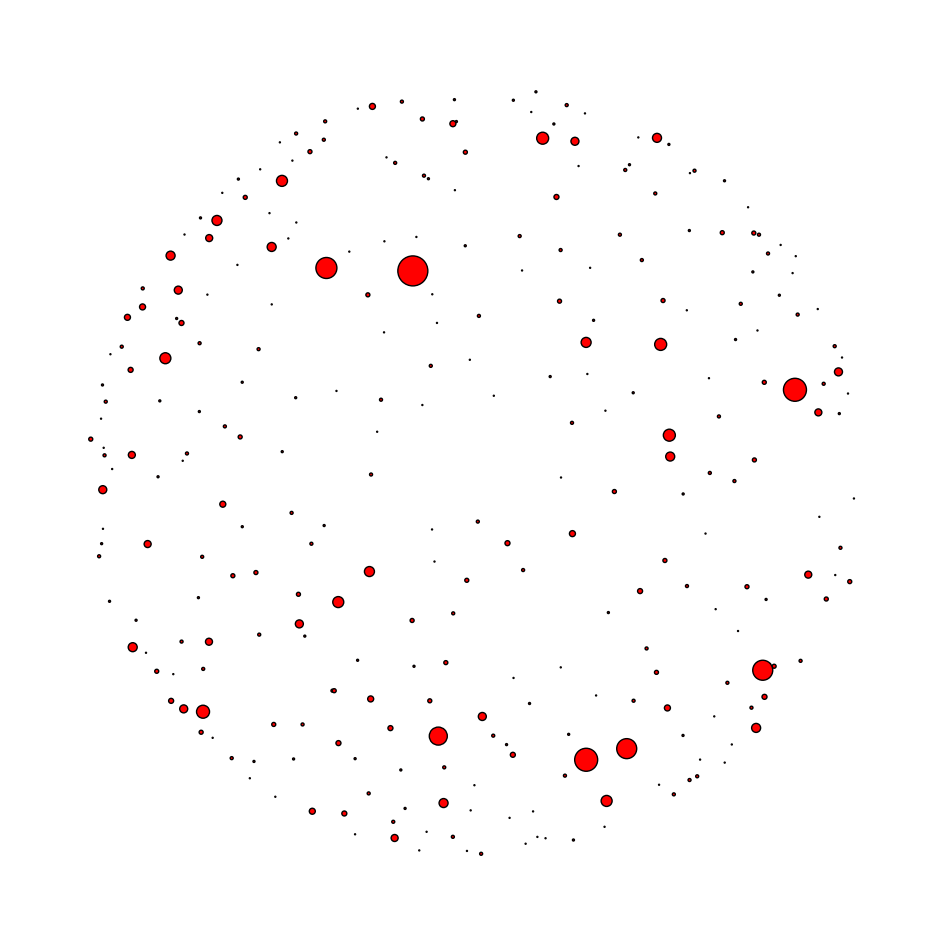

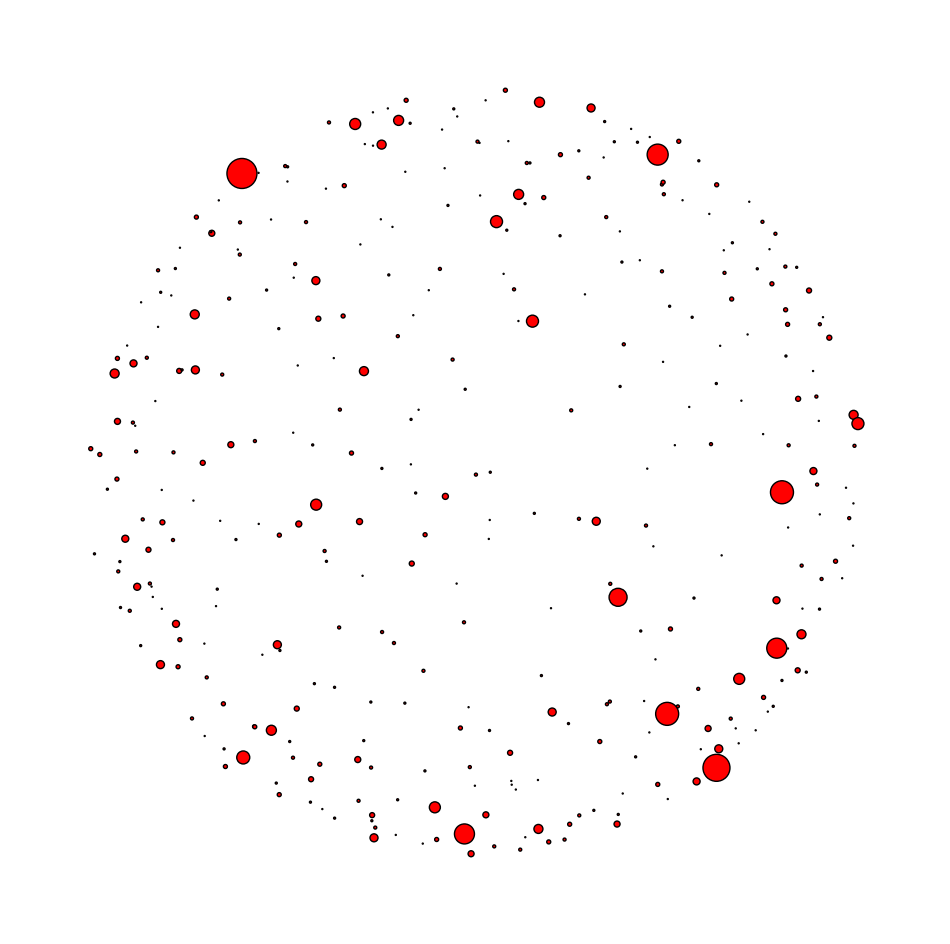

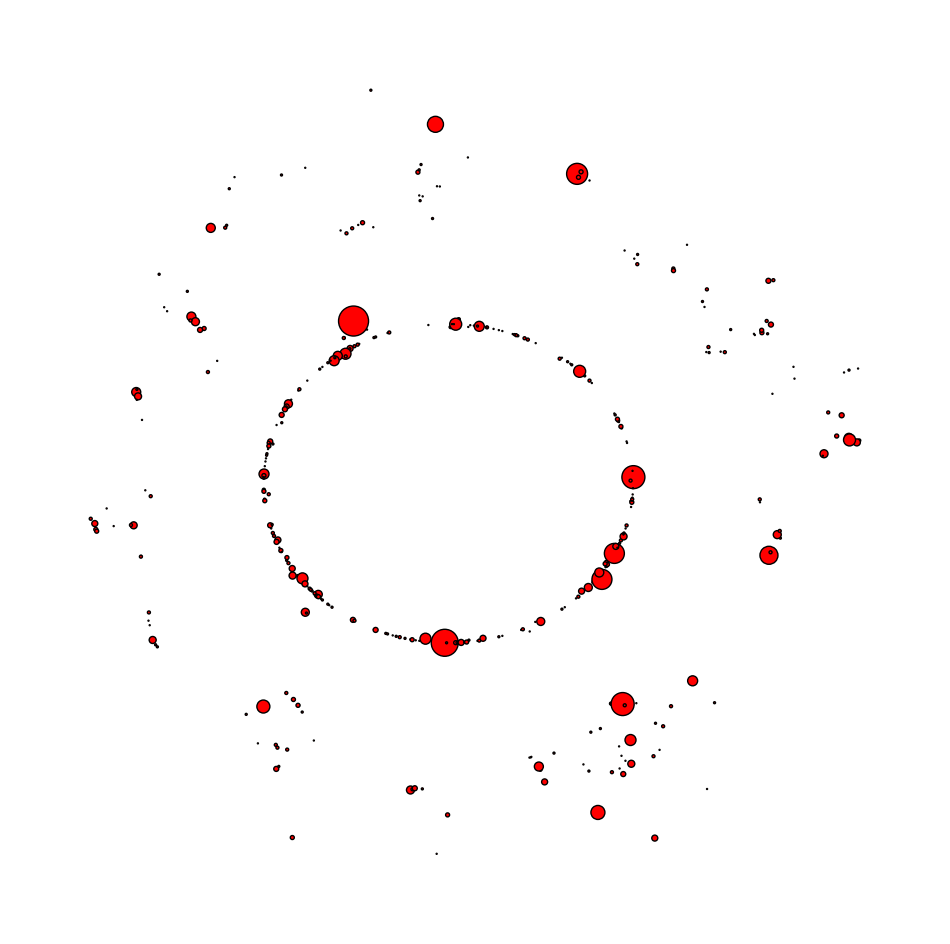

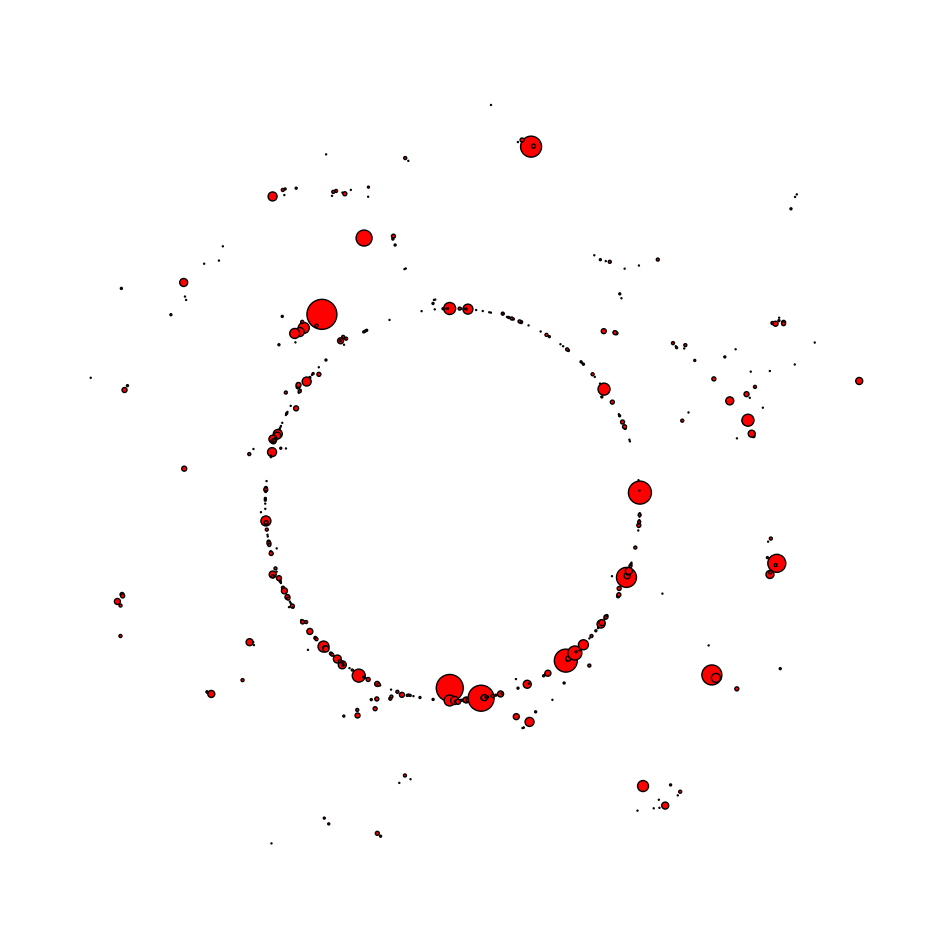

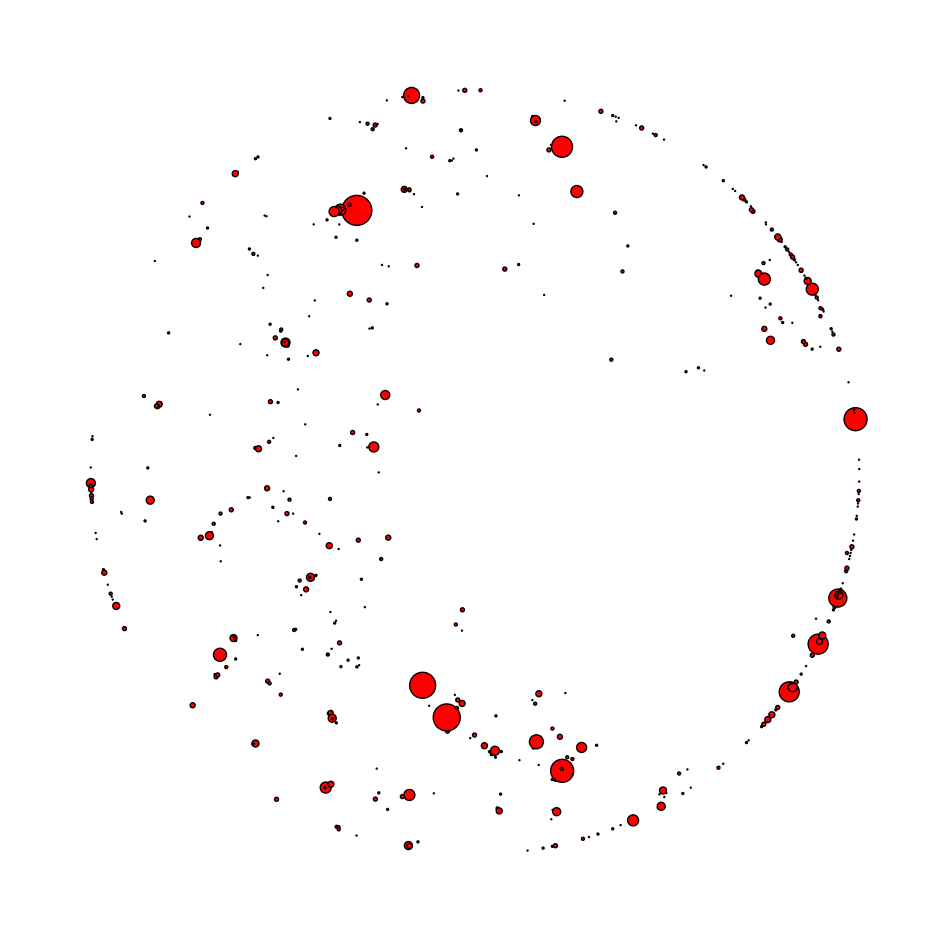

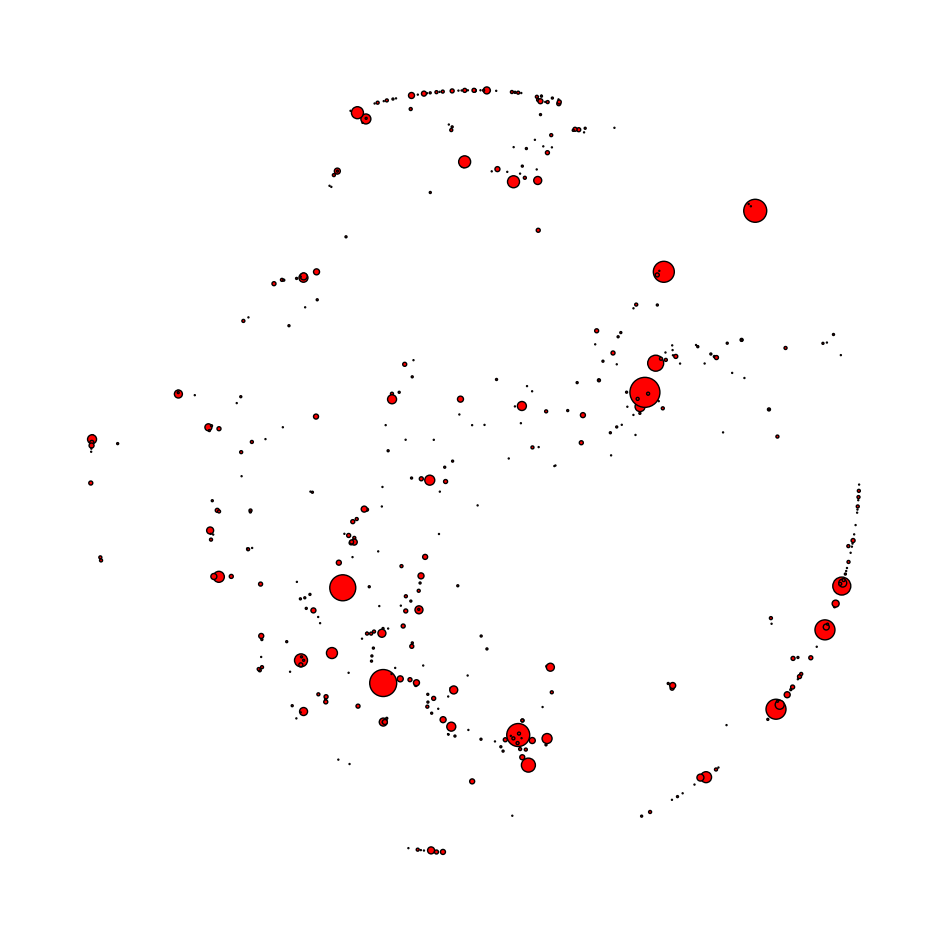

In [4]:
import igraph as ig
import matplotlib.pyplot as plt

radii = [2,4,6,8, 50, 100]
stationParisLimitedPerRadius = []

for i in radii:
    stationParisLimitedPerRadius.append(networkStationPairs[networkStationPairs["distance"] <= i])

for stationsPairsLimited in stationParisLimitedPerRadius:
    g = ig.Graph.TupleList(stationsPairsLimited.itertuples(index=False), weights=True)

    node_sizes = dict(zip(stationsWithDifferingGPS["posid"], stationsWithDifferingGPS["total_amt"].apply(lambda x: x / 100000)))

    g.vs["size"] = [node_sizes.get(posid, 1) for posid in g.vs["name"]]

    layout = g.layout("kamada_kawai", weights=g.es["weight"])

    fig, ax = plt.subplots(figsize=(12, 12))  # Larger figure size for better visualization
    ig.plot(g, layout=layout, target=ax, vertex_size=g.vs["size"], bbox=(0, 0, 1000, 1000), edge_width=0)

    plt.show()

In [5]:
stationsWithDifferingGPS

,gps_lat,gps_lon,total_amt,posid
0,48.587223,14.322222,17905.70,8062
1,48.619080,14.324732,106154.00,8685
2,48.624376,14.248910,13322.30,6390
3,48.637203,14.230956,134472.40,6440
4,48.649460,14.452580,2319653.78,5090
...,...,...,...,...
1910,50.984135,14.597880,295.40,5713
1915,51.000679,14.575062,4610.02,5712
1916,51.002682,14.464286,187055.20,7936
1918,51.024219,14.456202,5294.10,7937


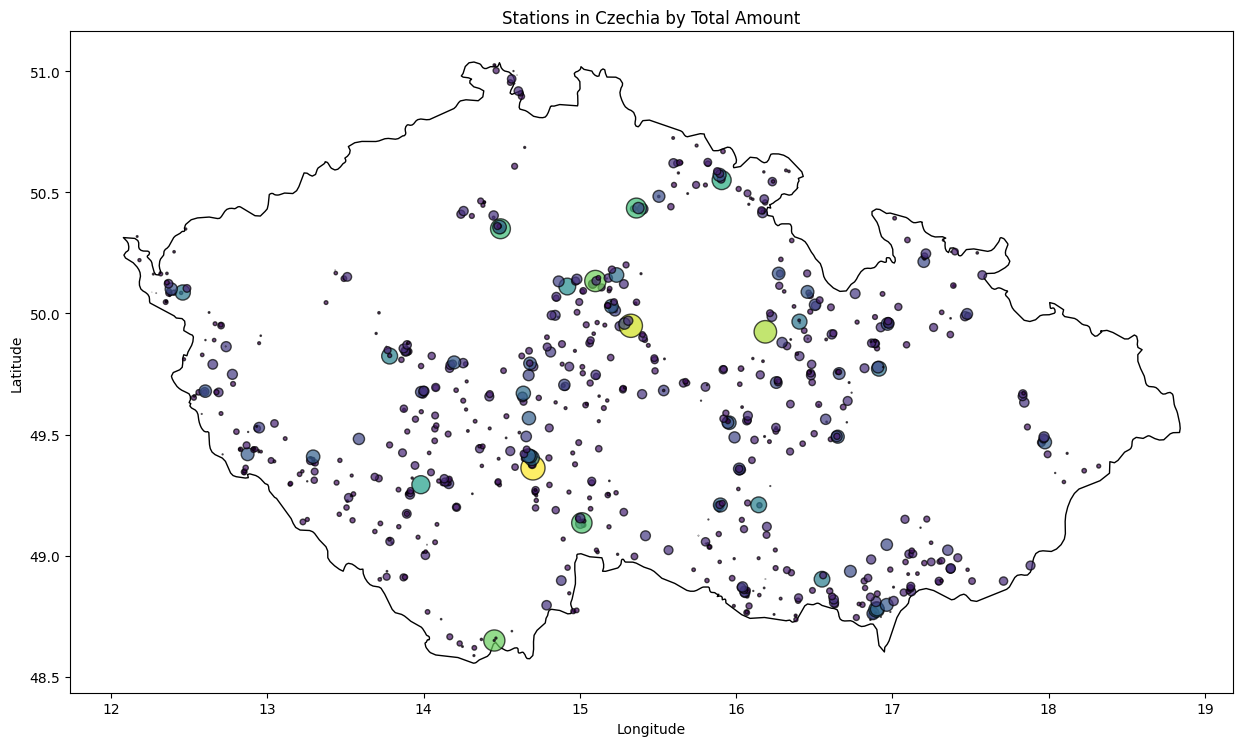

In [6]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point

world = gpd.read_file('./maps/ne_10m_admin_0_countries.shp')

czech_map = world[world['NAME'] == 'Czechia']

geometry = [Point(xy) for xy in zip(stationsWithDifferingGPS['gps_lon'], stationsWithDifferingGPS['gps_lat'])]

gdf_points = gpd.GeoDataFrame(stationsWithDifferingGPS, geometry=geometry, crs="EPSG:4326")

marker_sizes = gdf_points['total_amt'] * 0.0001  # Scale factor to adjust the size

fig, ax = plt.subplots(figsize=(15, 15))
czech_map.plot(ax=ax, color='white', edgecolor='black')

gdf_points.plot(
    ax=ax,
    column='total_amt',   # Color scale based on 'total_amt'
    cmap='viridis',       # Colormap
    markersize=marker_sizes,  # Size based on 'total_amt'
    alpha=0.7,            # Transparency for better visibility
    edgecolor='black'
)

plt.title('Stations in Czechia by Total Amount')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [7]:
networkStationPairs

,posid_1,posid_2,distance
0,8062,8685,3.547361
1,8062,8468,181.049844
2,8062,8300,197.211028
3,8062,8699,51.496025
4,8062,8863,131.573205
...,...,...,...
293756,7940,8735,40.190134
293757,7940,7968,87.177264
293758,7940,8475,18.811543
293759,7940,8472,17.574692


In [8]:
radii = [0.5,1, 2,4,6,7,8,10,20, 50, 100]
stationPairsLimitedPerRadius = []

for i in radii:
    stationPairsLimitedPerRadius.append(networkStationPairs[networkStationPairs["distance"] <= i])

In [9]:
stationInRadiusPerRadius = []
for stationsPairsLimited in stationPairsLimitedPerRadius:
    stationDistances = pd.melt(stationsPairsLimited, id_vars=['distance'], value_vars=['posid_1', 'posid_2'], 
                  var_name='pos_type', value_name='posid')

    stationDistances = stationDistances.drop('pos_type', axis=1)

    stationsInRadius = stationDistances.groupby("posid").agg(
        stations_in_radius=("distance", "count"),
        posid=("posid", "first")
    )

    stationsInRadius = stationsInRadius.set_index("posid").join(stationsWithDifferingGPS.set_index("posid"))
    stationsInRadius = stationsInRadius.drop(columns=["gps_lat", "gps_lon"])
    stationsInRadius = stationsInRadius.sort_values(by="total_amt")
    stationInRadiusPerRadius.append(stationsInRadius)

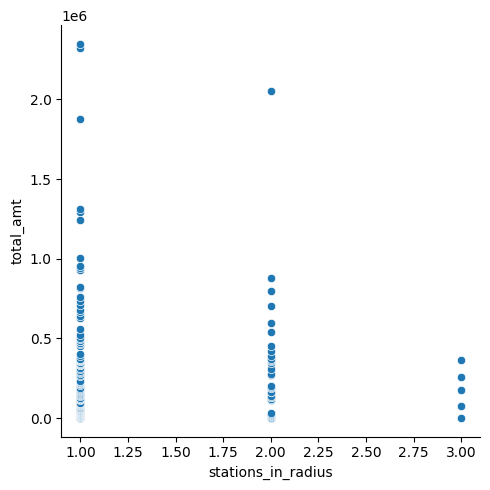

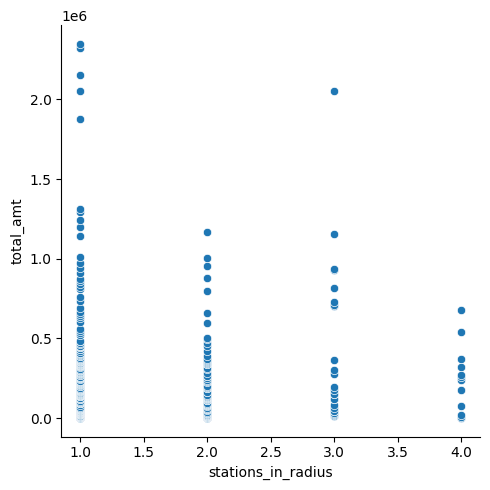

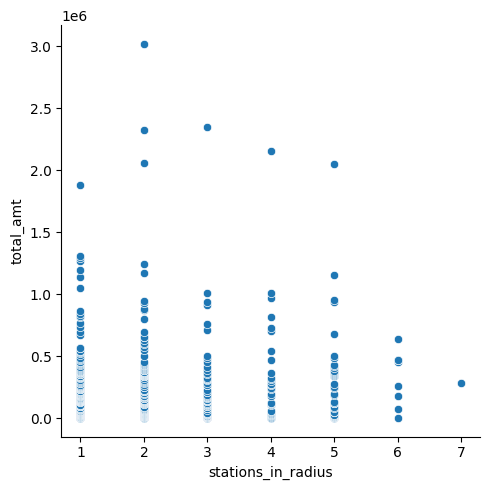

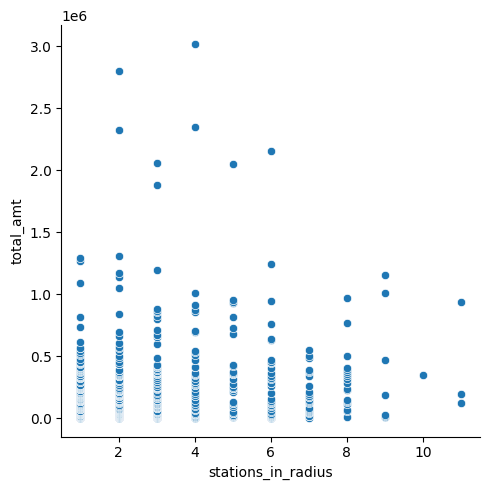

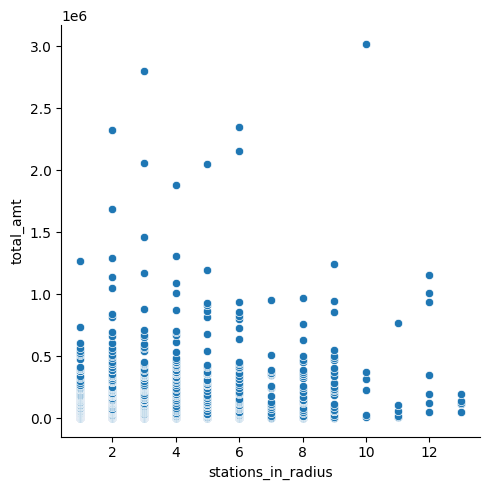

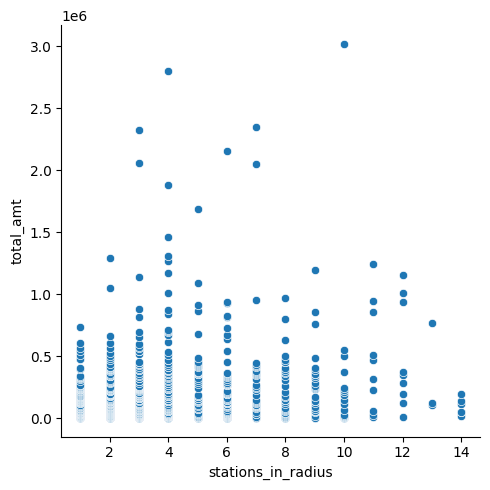

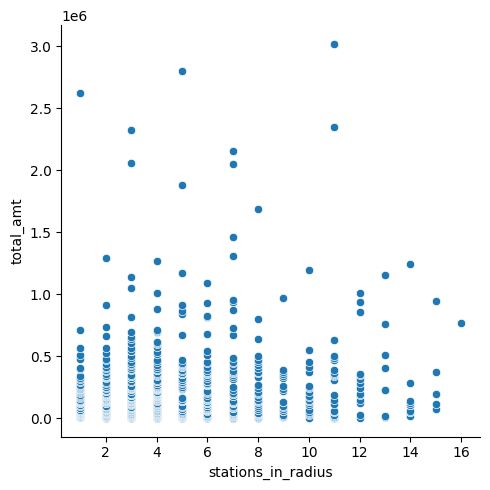

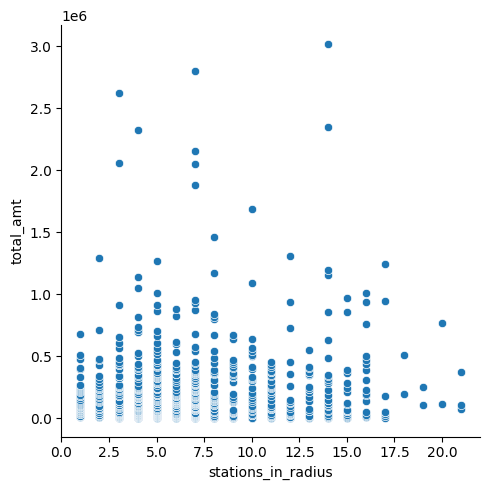

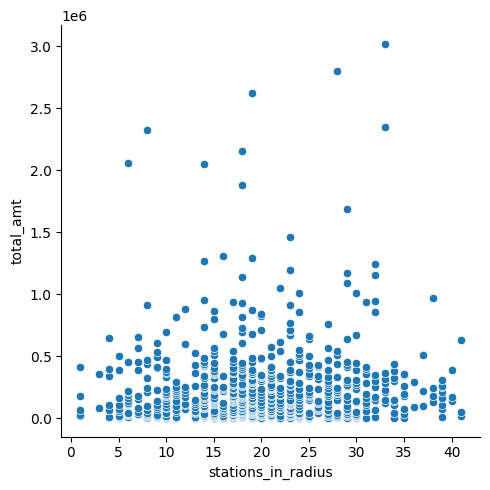

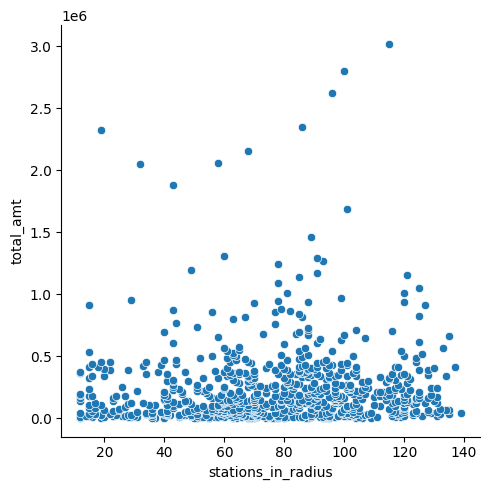

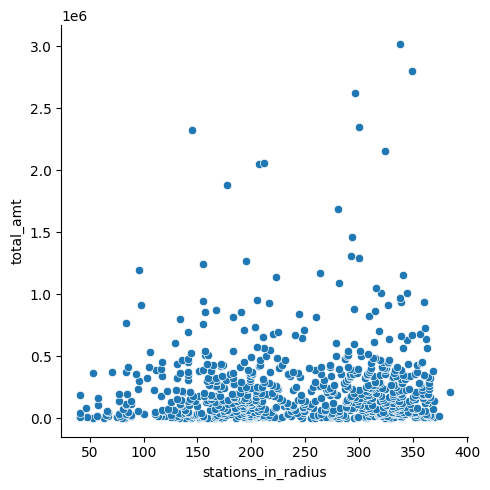

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("display.precision", 2)

for stationsInRadius in stationInRadiusPerRadius:
    g = sns.relplot(data=stationsInRadius, x="stations_in_radius", y="total_amt")

# Linear Regression

In [60]:
stationsInRadius = stationInRadiusPerRadius[6]
stationsInRadius

,stations_in_radius,total_amt
posid,,
7264,15,8.30e+01
37828,8,1.84e+02
5713,10,2.95e+02
5993,6,4.06e+02
37634,11,6.32e+02
...,...,...
8672,8,2.62e+06
4974,8,2.80e+06
4984,7,2.99e+06


In [20]:
stationsInRadius = stationInRadiusPerRadius[9]

X = stationsInRadius[['stations_in_radius']]
y = stationsInRadius['total_amt']

### fit model
modelA = LinearRegression().fit(X, y)

### get coefficients
print('Intercept: ', modelA.intercept_)
print('Beta coefficients: ', modelA.coef_)

### assess coefficients / drop predictors
# There is no straight way (like p-value). We can use performance metric and assess it;
# then we can fit a submodel and compare performance metrics.

### assess model performance
# i. scoring itself directly (not recommended, overrates performance)
print('R2 on itself: ', modelA.score(X, y))

# ii. scoring by a cross-validation
scores = cross_val_score(LinearRegression(), X, y, cv=4)
print('R2 by cval: ', scores)

### predictions
x_pred = 10 # prediction of amount for 2 stations in radius
print('Predicted intake for stations in radius', x_pred, ' is ', modelA.predict([[x_pred]]))
# predictions can be made on actual predictor values, too -> added to the chart

Intercept:  184142.9719995544
Beta coefficients:  [777.27416834]
R2 on itself:  0.004921511233017206
R2 by cval:  [-478.02281457  -41.29035145   -0.8702383    -1.28246157]
Predicted intake for stations in radius 10  is  [191915.71368293]


c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [96]:
X_int = sm.add_constant(X)
# by default the intercept is NOT included - we need to add it

### fit model
modelB = sm.OLS(y, X_int).fit()

### get coefficients
print('Beta coefficients: ', modelB.params)

### assess coefficients / drop predictors
print(modelB.summary()) # detailed information of model and coefficients

### assess model
# i. scoring itself directly (not recommended, overrates performance)
print('R2 on itself: ', modelB.rsquared)
# ii. scoring by a cross-validation
# cross-validation not available in this package, we can use approximation:
print('R2 adjusted: ', modelB.rsquared_adj)

### predictions
x_pred = 2 # prediction of salary for 35 yrs old
print('Predicted intake for stations in radius', x_pred, ' is ', modelB.predict([1, x_pred]))

Beta coefficients:  const                 1.50e+06
stations_in_radius   -1.20e+05
dtype: float64
                            OLS Regression Results                            
Dep. Variable:              total_amt   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     6.136
Date:                Fri, 10 Jan 2025   Prob (F-statistic):             0.0144
Time:                        18:07:00   Log-Likelihood:                -2366.0
No. Observations:                 152   AIC:                             4736.
Df Residuals:                     150   BIC:                             4742.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

In [98]:
X = stationsInRadius[['stations_in_radius']]
y = stationsInRadius['total_amt']

# A. sklearn
modelA = LinearRegression().fit(X, y)
# and everything is the same...
print('Intercept: ', modelA.intercept_)
print('Beta coefficients: ', modelA.coef_)
print('R2 on itself: ', modelA.score(X, y))
scores = cross_val_score(LinearRegression(), X, y, cv=4)
print('R2 by cval: ', scores)
# except prediction - it must use follow dummy (one-hot) encoding, i.e. "male" -> sex_M=1
x_pred = 3
print('Predicted intake for stations in radius ', x_pred, ' is ', modelA.predict([[x_pred]]))

Intercept:  1504468.6525603018
Beta coefficients:  [-120005.46221859]
R2 on itself:  0.039301784849202326
R2 by cval:  [-641.25161302  -58.76132866   -3.81107109   -2.44281656]
Predicted intake for stations in radius  3  is  [1144452.26590452]


c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
